In [1]:
# Si ejecutas este notebook en Google Colab, revisa esta guía oficial:
# https://docs.pytorch.org/tutorials/beginner/colab
# Muestra gráficos de Matplotlib incrustados dentro del notebook.
%matplotlib inline

[Introduction](introyt1_tutorial.html) \|\|
[Tensors](tensors_deeper_tutorial.html) \|\|
[Autograd](autogradyt_tutorial.html) \|\| [Building
Models](modelsyt_tutorial.html) \|\| [TensorBoard
Support](tensorboardyt_tutorial.html) \|\| **Training Models** \|\|
[Model Understanding](captumyt.html)

Training with PyTorch
=====================

Follow along with the video below or on
[youtube](https://www.youtube.com/watch?v=jF43_wj_DCQ).



In [2]:
# Importa utilidades para renderizar HTML dentro del notebook.
from IPython.display import display, HTML
# Define un bloque HTML que incrusta el vídeo de YouTube del tutorial.
html_code = """
<div style="margin-top:10px; margin-bottom:10px;">
  <iframe width="560" height="315" src="https://www.youtube.com/embed/jF43_wj_DCQ" frameborder="0" allow="accelerometer; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe>
</div>
"""
# Renderiza el HTML para que el vídeo se vea en la salida de la celda.
display(HTML(html_code))



Introduction
------------

In past videos, we've discussed and demonstrated:

-   Building models with the neural network layers and functions of the
    torch.nn module
-   The mechanics of automated gradient computation, which is central to
    gradient-based model training
-   Using TensorBoard to visualize training progress and other
    activities

In this video, we'll be adding some new tools to your inventory:

-   We'll get familiar with the dataset and dataloader abstractions, and
    how they ease the process of feeding data to your model during a
    training loop
-   We'll discuss specific loss functions and when to use them
-   We'll look at PyTorch optimizers, which implement algorithms to
    adjust model weights based on the outcome of a loss function

Finally, we'll pull all of these together and see a full PyTorch
training loop in action.

Dataset and DataLoader
----------------------

The `Dataset` and `DataLoader` classes encapsulate the process of
pulling your data from storage and exposing it to your training loop in
batches.

The `Dataset` is responsible for accessing and processing single
instances of data.

The `DataLoader` pulls instances of data from the `Dataset` (either
automatically or with a sampler that you define), collects them in
batches, and returns them for consumption by your training loop. The
`DataLoader` works with all kinds of datasets, regardless of the type of
data they contain.

For this tutorial, we'll be using the Fashion-MNIST dataset provided by
TorchVision. We use `torchvision.transforms.Normalize()` to zero-center
and normalize the distribution of the image tile content, and download
both training and validation data splits.


In [3]:
# Importa PyTorch para tensores, entrenamiento y utilidades base.
import torch
# Importa TorchVision para datasets de visión y utilidades relacionadas.
import torchvision
# Importa transformaciones de preprocesado de imágenes.
import torchvision.transforms as transforms

# Importa SummaryWriter para registrar métricas en TensorBoard.
from torch.utils.tensorboard import SummaryWriter
# Importa datetime para crear nombres únicos con timestamp.
from datetime import datetime

# Encadena transformaciones de entrada para el dataset.
"""                         --- IMPORTANTE ---
La transformacion se ejecuta cuando se hace training_set[idx] o cuando DataLoader arma batches.
No se realiza en la asignación de la variable training_set, sino que se aplica dinámicamente a cada imagen cuando se accede a ella.
"""
transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))])

# Crea el conjunto de entrenamiento de FashionMNIST (descarga si no existe).
training_set = torchvision.datasets.FashionMNIST('./data', train=True, transform=transform, download=True)
print(f'Tipo de training_set: {type(training_set)}')
# Crea el conjunto de validación/prueba de FashionMNIST.
validation_set = torchvision.datasets.FashionMNIST('./data', train=False, transform=transform, download=True)
print(f'Tipo de validation_set: {type(validation_set)}')


"""                         ---- DIFERENCIAS ENTRE DATASET Y TENSORDATASET ----
training_set es un objeto de la clase torchvision.datasets.FashionMNIST, que hereda de torch.utils.data.Dataset (Es un DATASET).

No es lo mismo que un TensorDataset ni un Tensor.

Se puede transformar un Dataset a un TensorDataset asi:
X = training_set.data.float() / 255.0     
y = training_set.targets
ds = torch.utils.data.TensorDataset(X, y)

"""

# DataLoader de entrenamiento: batch de 4 y mezcla aleatoria de muestras.
training_loader = torch.utils.data.DataLoader(training_set, batch_size=4, shuffle=True)
print(f'Tipo de training_loader: {type(training_loader)}')
# DataLoader de validación: batch de 4 y sin mezcla para evaluación estable.
validation_loader = torch.utils.data.DataLoader(validation_set, batch_size=4, shuffle=False)
print(f'Tipo de validation_loader: {type(validation_loader)}')

# Tupla con nombres entendibles de las 10 clases del dataset.
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')

# Imprime el número total de ejemplos disponibles en entrenamiento.
print('Training set has {} instances'.format(len(training_set)))
print(f'Shape de training_set (caracteristicas de cada instancia): {training_set.data.shape}')
print(f'Shape de training_set.targets (etiquetas de cada instancia): {training_set.targets.shape}')
print(f'Clases de salida ({len(training_set.classes)}): {training_set.classes}')
print(f'Mapeo clase -> índice: {training_set.class_to_idx}\n')

# Imprime el número total de ejemplos disponibles en validación.
print('Validation set has {} instances'.format(len(validation_set)))
print(f'Shape de validation_set (caracteristicas de cada instancia): {validation_set.data.shape}')
print(f'Shape de validation_set.targets (etiquetas de cada instancia): {validation_set.targets.shape}')
print(f'Clases de salida ({len(validation_set.classes)}): {validation_set.classes}')
print(f'Mapeo clase -> índice: {validation_set.class_to_idx}\n')    

print(f'Numero de batches en training_loader: {training_loader.__len__()}')
print(f'Numero de batches en validation_loader: {validation_loader.__len__()}')

Tipo de training_set: <class 'torchvision.datasets.mnist.FashionMNIST'>
Tipo de validation_set: <class 'torchvision.datasets.mnist.FashionMNIST'>
Tipo de training_loader: <class 'torch.utils.data.dataloader.DataLoader'>
Tipo de validation_loader: <class 'torch.utils.data.dataloader.DataLoader'>
Training set has 60000 instances
Shape de training_set (caracteristicas de cada instancia): torch.Size([60000, 28, 28])
Shape de training_set.targets (etiquetas de cada instancia): torch.Size([60000])
Clases de salida (10): ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Mapeo clase -> índice: {'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}

Validation set has 10000 instances
Shape de validation_set (caracteristicas de cada instancia): torch.Size([10000, 28, 28])
Shape de validation_set.targets (etiquetas de cada instancia): torch.Size([10000])
Clase

INCISO
======
### Mini bloque: diferencias entre `torch.tensor()`, `torch.from_numpy()` y `transforms.ToTensor()`

1. **`torch.tensor(...)`**
- Crea un tensor **nuevo copiando datos**.
- Acepta listas, tuplas, arrays de NumPy, etc.
- No comparte memoria con el origen.

2. **`torch.from_numpy(ndarray)`**
- Convierte un `np.ndarray` a tensor **sin copiar** (normalmente).
- **Comparte memoria** con NumPy: si cambias uno, cambia el otro.
- Solo aplica a arrays de NumPy y se crea en CPU.

3. **`transforms.ToTensor()`**
- Es una transformación de `torchvision` pensada para **imágenes**.
- Convierte típicamente de `PIL`/NumPy en formato `H x W x C` a tensor `C x H x W`.
- Para imágenes `uint8`, suele escalar valores de `[0, 255]` a `[0.0, 1.0]`.

**Regla rápida:**
- Datos generales: `torch.tensor(...)`
- Si ya tienes NumPy y quieres eficiencia: `torch.from_numpy(...)`
- Si trabajas con imágenes en `torchvision`: `transforms.ToTensor()`

In [7]:
# Mini ejemplo práctico: torch.tensor vs torch.from_numpy vs transforms.ToTensor
import numpy as np
from torchvision import transforms

# 1) torch.tensor(...) -> copia datos
arr = np.array([[1, 2], [3, 4]], dtype=np.float32)
t_copy = torch.tensor(arr)
arr[0, 0] = 999
print('torch.tensor (copia) -> t_copy[0,0]:', t_copy[0, 0].item())  # sigue en 1.0

# 2) torch.from_numpy(...) -> comparte memoria con NumPy
arr2 = np.array([[1, 2], [3, 4]], dtype=np.float32)
t_shared = torch.from_numpy(arr2)
arr2[0, 0] = 999
print('torch.from_numpy (memoria compartida) -> t_shared[0,0]:', t_shared[0, 0].item())  # ahora 999.0

# 3) transforms.ToTensor() -> pensado para imágenes HWC uint8
img_np = np.random.randint(0, 256, size=(28, 28, 1), dtype=np.uint8)  # H x W x C
print(f'Tipo de img_np: {type(img_np)}, shape {img_np.shape} y contenido de imag_np:\n {img_np}\n')
img_t = transforms.ToTensor()(img_np)
print(img_t)

print('ToTensor shape (C,H,W):', tuple(img_t.shape))
print('ToTensor dtype:', img_t.dtype)
print('ToTensor rango aprox [0,1]:', float(img_t.min()), float(img_t.max()))

torch.tensor (copia) -> t_copy[0,0]: 1.0
torch.from_numpy (memoria compartida) -> t_shared[0,0]: 999.0
Tipo de img_np: <class 'numpy.ndarray'>, shape (28, 28, 1) y contenido de imag_np:
 [[[ 89]
  [ 71]
  [ 50]
  [ 61]
  [204]
  [ 31]
  [ 61]
  [ 37]
  [113]
  [ 70]
  [ 89]
  [245]
  [121]
  [100]
  [ 32]
  [109]
  [ 50]
  [142]
  [ 12]
  [205]
  [  4]
  [233]
  [166]
  [101]
  [253]
  [100]
  [153]
  [ 16]]

 [[ 13]
  [181]
  [169]
  [ 28]
  [ 30]
  [175]
  [189]
  [ 47]
  [ 91]
  [169]
  [ 60]
  [138]
  [191]
  [ 57]
  [160]
  [154]
  [171]
  [ 31]
  [120]
  [209]
  [ 19]
  [ 26]
  [ 60]
  [234]
  [ 37]
  [ 16]
  [ 92]
  [ 51]]

 [[213]
  [127]
  [ 41]
  [ 16]
  [  0]
  [252]
  [ 65]
  [113]
  [171]
  [243]
  [246]
  [209]
  [ 31]
  [148]
  [115]
  [ 87]
  [ 11]
  [ 61]
  [ 40]
  [ 53]
  [102]
  [231]
  [ 81]
  [ 17]
  [  2]
  [135]
  [238]
  [105]]

 [[ 41]
  [108]
  [139]
  [235]
  [ 87]
  [ 41]
  [245]
  [ 73]
  [140]
  [  4]
  [165]
  [224]
  [242]
  [101]
  [141]
  [ 50]
  [135]

CONTINUACIÓN TRAS INCISO
========================
As always, let's visualize the data as a sanity check:


Tipo y shape de images: <class 'torch.Tensor'>, torch.Size([4, 1, 28, 28])
Tipo y shape de labels: <class 'torch.Tensor'>, torch.Size([4])
Clases del batch: Dress, Sandal, Sneaker, Sneaker


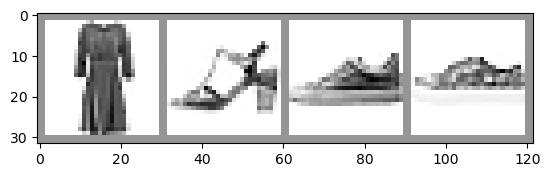

In [10]:
# Importa Matplotlib para visualizar imágenes.
import matplotlib.pyplot as plt
# Importa NumPy para manipulación de arrays al visualizar.
import numpy as np

# Define una función auxiliar para mostrar un tensor de imagen con Matplotlib.
def matplotlib_imshow(img, one_channel=False):
    # Si se solicita modo monocanal, promedia los canales de color.
    if one_channel:
        img = img.mean(dim=0)
    # Desnormaliza de vuelta para visualizar valores en rango visible.
    img = img / 2 + 0.5
    # Convierte el tensor de PyTorch en array de NumPy.
    npimg = img.numpy()
    # Si es monocanal, usa mapa de color en escala de grises.
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        # Si es multicanal, cambia de formato CHW (PyTorch) a HWC (Matplotlib).
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

# Crea un iterador sobre el DataLoader de entrenamiento.
dataiter = iter(training_loader)
# Obtiene el siguiente batch: imágenes y etiquetas.
images, labels = next(dataiter)

# El tensor [4, 1, 28, 28] representa un batch de 4 imágenes, cada una con 1 canal y tamaño 28x28.
# Es decir, 4 patrones con sus 28x28 píxeles en escala de grises.
print(f'Tipo y shape de images: {type(images)}, {images.shape}')
print(f'Tipo y shape de labels: {type(labels)}, {labels.shape}')

# Construye una cuadrícula visual con las imágenes del batch.
img_grid = torchvision.utils.make_grid(images)
# Muestra la cuadrícula en modo monocanal.
matplotlib_imshow(img_grid, one_channel=True)
# Imprime los nombres de las clases de las 4 imágenes del batch.
print('Clases del batch: ' + ', '.join(classes[labels[j].item()] for j in range(len(labels))))

The Model
=========

The model we'll use in this example is a variant of LeNet-5 - it should
be familiar if you've watched the previous videos in this series.


In [12]:
# Importa el módulo de capas y contenedores de redes neuronales.
import torch.nn as nn
# Importa funciones auxiliares como activaciones (ReLU, etc.).
import torch.nn.functional as F

# Define un clasificador de prendas heredando de nn.Module.
class GarmentClassifier(nn.Module):
    # Constructor donde se declaran las capas del modelo.
    def __init__(self):
        # Inicializa correctamente la clase base de PyTorch.
        super(GarmentClassifier, self).__init__()
        # Primera convolución: 1 canal de entrada -> 6 mapas de características. kernel de 5x5.
        """
        self.conv1 = nn.Conv2d(1, 6, 5) espera una entrada con forma:

            - [batch_size, 1, alto, ancho]

        En este caso (Fashion-MNIST), cada imagen es escala de grises de 28x28, entonces típicamente entra:

            - una muestra: [1, 28, 28] (sin batch, si la pasas individualmente)
            - un batch: [B, 1, 28, 28] (por ejemplo [4, 1, 28, 28])
        """        
        self.conv1 = nn.Conv2d(1, 6, 5)
        
        # MaxPooling 2x2 para reducir tamaño espacial.
        self.pool = nn.MaxPool2d(2, 2)
        
        # Segunda convolución: 6 canales (los 6 mapas de características ya reducidos de la capa anterior) -> 16 mapas de características.
        # Cada uno de esos 6 canales son las 6 salidas de conv1 detecta patrones distintos (bordes, texturas, formas simples).
        self.conv2 = nn.Conv2d(6, 16, 5)
        
        # Primera capa totalmente conectada.
        """
        En esta red:

                Entrada: 1 x 28 x 28
                conv1(1->6, kernel=5, stride=1, padding=0)
                Salida espacial: 28 - 5 + 1 = 24
                Queda: 6 x 24 x 24
                maxpool(2x2)
                Queda: 6 x 12 x 12
                conv2(6->16, kernel=5)
                Salida espacial: 12 - 5 + 1 = 8
                Queda: 16 x 8 x 8
                maxpool(2x2)
                Queda: 16 x 4 x 4
        """
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        
        # Segunda capa totalmente conectada.
        self.fc2 = nn.Linear(120, 84)
        
        # Capa de salida con 10 logits (uno por clase).
        self.fc3 = nn.Linear(84, 10)

    # Define el flujo de datos al hacer forward pass.
    def forward(self, x):
        # Conv1 -> ReLU -> Pooling.
        x = self.pool(F.relu(self.conv1(x)))
        # Conv2 -> ReLU -> Pooling.
        x = self.pool(F.relu(self.conv2(x)))
        # Aplana el tensor 3D por muestra para pasar a capas lineales.
        # Antes de la capa lineal haces x.view(-1, 16*4*4), 
        # así que cada imagen aporta 16*4*4 = 256 características.
        x = x.view(-1, 16 * 4 * 4)
        # Capa densa + activación ReLU.
        x = F.relu(self.fc1(x))
        # Capa densa + activación ReLU.
        x = F.relu(self.fc2(x))
        # Capa final sin activación para producir logits.
        x = self.fc3(x)
        # Devuelve logits para usar con CrossEntropyLoss.
        return x
    

# Crea una instancia del modelo.
model = GarmentClassifier()

Loss Function
=============

For this example, we'll be using a cross-entropy loss. For demonstration
purposes, we'll create batches of dummy output and label values, run
them through the loss function, and examine the result.


In [13]:
# Define la función de pérdida de clasificación multiclase.
loss_fn = torch.nn.CrossEntropyLoss()

# Nota: la pérdida espera datos en batches; aquí usamos batch_size=4.
# Simula salida del modelo: 4 muestras x 10 clases (logits aleatorios).
dummy_outputs = torch.rand(4, 10)
# Simula etiquetas correctas (índices de clase) para esas 4 muestras.
dummy_labels = torch.tensor([1, 5, 3, 7])
    
# Muestra los logits simulados.
print(dummy_outputs)
# Muestra las etiquetas simuladas.
print(dummy_labels)

# Calcula la pérdida total del batch simulado.
loss = loss_fn(dummy_outputs, dummy_labels)
# Convierte la pérdida escalar a float de Python para imprimirla.
print('Total loss for this batch: {}'.format(loss.item()))

tensor([[0.1982, 0.0191, 0.2879, 0.3542, 0.7037, 0.0250, 0.4685, 0.3476, 0.5406,
         0.2851],
        [0.8561, 0.4544, 0.9893, 0.2252, 0.9490, 0.1528, 0.4288, 0.3908, 0.1334,
         0.5757],
        [0.5844, 0.8431, 0.0653, 0.8900, 0.9330, 0.9122, 0.7283, 0.8424, 0.3182,
         0.1840],
        [0.5957, 0.4890, 0.9707, 0.2197, 0.3652, 0.6752, 0.0035, 0.7491, 0.4483,
         0.7311]])
tensor([1, 5, 3, 7])
Total loss for this batch: 2.3848490715026855


Optimizer
=========

For this example, we'll be using simple [stochastic gradient
descent](https://pytorch.org/docs/stable/optim.html) with momentum.

It can be instructive to try some variations on this optimization
scheme:

-   Learning rate determines the size of the steps the optimizer takes.
    What does a different learning rate do to the your training results,
    in terms of accuracy and convergence time?
-   Momentum nudges the optimizer in the direction of strongest gradient
    over multiple steps. What does changing this value do to your
    results?
-   Try some different optimization algorithms, such as averaged SGD,
    Adagrad, or Adam. How do your results differ?


In [14]:
# Crea un optimizador SGD sobre los parámetros del modelo.
# lr controla el tamaño de paso y momentum suaviza la dirección de actualización.
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

The Training Loop
=================

Below, we have a function that performs one training epoch. It
enumerates data from the DataLoader, and on each pass of the loop does
the following:

-   Gets a batch of training data from the DataLoader
-   Zeros the optimizer's gradients
-   Performs an inference - that is, gets predictions from the model for
    an input batch
-   Calculates the loss for that set of predictions vs. the labels on
    the dataset
-   Calculates the backward gradients over the learning weights
-   Tells the optimizer to perform one learning step - that is, adjust
    the model's learning weights based on the observed gradients for
    this batch, according to the optimization algorithm we chose
-   It reports on the loss for every 1000 batches.
-   Finally, it reports the average per-batch loss for the last 1000
    batches, for comparison with a validation run


In [15]:
# Define una función que entrena exactamente una época.
def train_one_epoch(epoch_index, tb_writer):
    # Acumula pérdida de entrenamiento para reportes periódicos.
    running_loss = 0.
    # Guarda el último promedio calculado (cada 1000 batches).
    last_loss = 0.
    
    # enumerate(training_loader) entrega índice de batch y datos en cada iteración.
    for i, data in enumerate(training_loader):
        # Cada elemento de data es una tupla: (inputs, labels).
        inputs, labels = data
        
        # Reinicia gradientes para no acumular del batch anterior.
        optimizer.zero_grad()
        
        # Forward: obtiene predicciones del modelo para este batch.
        outputs = model(inputs)
        
        # Calcula pérdida comparando predicciones y etiquetas reales.
        loss = loss_fn(outputs, labels)
        # Backward: propaga gradientes hacia atrás por toda la red.
        loss.backward()
        
        # Actualiza los pesos usando el optimizador configurado.
        optimizer.step()
        
        # Suma la pérdida del batch para sacar promedio cada 1000 pasos.
        running_loss += loss.item()
        # Cada 1000 batches imprime y registra en TensorBoard.
        if i % 1000 == 999:
            # Promedio de pérdida por batch en este tramo.
            last_loss = running_loss / 1000
            # Muestra en consola el progreso intra-época.
            print('  batch {} loss: {}'.format(i + 1, last_loss))
            # Calcula el eje X global para TensorBoard.
            tb_x = epoch_index * len(training_loader) + i + 1
            # Registra la pérdida de entrenamiento en TensorBoard.
            tb_writer.add_scalar('Loss/train', last_loss, tb_x)
            # Reinicia acumulador para el siguiente tramo.
            running_loss = 0.
            
    # Devuelve el último promedio de pérdida calculado.
    return last_loss

Per-Epoch Activity
==================

There are a couple of things we'll want to do once per epoch:

-   Perform validation by checking our relative loss on a set of data
    that was not used for training, and report this
-   Save a copy of the model

Here, we'll do our reporting in TensorBoard. This will require going to
the command line to start TensorBoard, and opening it in another browser
tab.


In [16]:
# Genera un timestamp para identificar de forma única esta ejecución.
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
# Crea el escritor de TensorBoard en una carpeta de logs con timestamp.
writer = SummaryWriter('runs/fashion_trainer_{}'.format(timestamp))
# Inicializa contador de época.
epoch_number = 0

# Define cuántas épocas de entrenamiento ejecutar.
EPOCHS = 5

# Inicializa la mejor pérdida de validación con un valor grande.
best_vloss = 1_000_000.

# Bucle principal de entrenamiento por épocas.
for epoch in range(EPOCHS):
    # Muestra número de época (arrancando en 1 para legibilidad).
    print('EPOCH {}:'.format(epoch_number + 1))
    
    # Activa modo entrenamiento (habilita comportamiento de train).
    model.train(True)
    # Ejecuta una época completa de entrenamiento y obtiene pérdida media reportada.
    avg_loss = train_one_epoch(epoch_number, writer)
    

    # Inicializa acumulador de pérdida de validación.
    running_vloss = 0.0
    # Cambia a modo evaluación: desactiva dropout y usa estadísticas de población.
    model.eval()

    # Desactiva cálculo de gradientes para ahorrar memoria y cómputo en validación.
    with torch.no_grad():
        # Recorre todos los batches del conjunto de validación.
        for i, vdata in enumerate(validation_loader):
            # Separa entradas y etiquetas de validación.
            vinputs, vlabels = vdata
            # Forward en validación.
            voutputs = model(vinputs)
            # Calcula pérdida de validación del batch actual.
            vloss = loss_fn(voutputs, vlabels)
            # Acumula pérdida de validación.
            running_vloss += vloss
    
    # Calcula pérdida media de validación por batch.
    avg_vloss = running_vloss / (i + 1)
    # Muestra en consola pérdida de train y validación.
    print('LOSS train {} valid {}'.format(avg_loss, avg_vloss))
    
    # Registra en TensorBoard ambas curvas: entrenamiento y validación.
    writer.add_scalars('Training vs. Validation Loss',
                    { 'Training' : avg_loss, 'Validation' : avg_vloss },
                    epoch_number + 1)
    # Fuerza la escritura de logs al disco.
    writer.flush()
    
    # Si mejora validación, guarda checkpoint del modelo.
    if avg_vloss < best_vloss:
        # Actualiza la mejor pérdida observada.
        best_vloss = avg_vloss
        # Construye nombre de archivo del modelo guardado.
        model_path = 'model_{}_{}'.format(timestamp, epoch_number)
        # Guarda solo los pesos (state_dict) del modelo.
        torch.save(model.state_dict(), model_path)
    
    # Avanza contador de época.
    epoch_number += 1

EPOCH 1:
  batch 1000 loss: 1.9480166400969028
  batch 2000 loss: 0.783034771037288
  batch 3000 loss: 0.6709274622150697
  batch 4000 loss: 0.6141008234811015
  batch 5000 loss: 0.5572190301578958
  batch 6000 loss: 0.5597063152461779
  batch 7000 loss: 0.4904832564659882
  batch 8000 loss: 0.5144205177589319
  batch 9000 loss: 0.4921684251944535
  batch 10000 loss: 0.4823972546947189
  batch 11000 loss: 0.4466150552846957
  batch 12000 loss: 0.4131538158630719
  batch 13000 loss: 0.42577669101714855
  batch 14000 loss: 0.4212393958439352
  batch 15000 loss: 0.41266670734120997
LOSS train 0.41266670734120997 valid 0.42489057779312134
EPOCH 2:
  batch 1000 loss: 0.4030000959197059
  batch 2000 loss: 0.3949399599642493
  batch 3000 loss: 0.40265693379403095
  batch 4000 loss: 0.3958158698422485
  batch 5000 loss: 0.38336387360445223
  batch 6000 loss: 0.37825631027976486
  batch 7000 loss: 0.3615161846682895
  batch 8000 loss: 0.35838352792814837
  batch 9000 loss: 0.36549294511449987
 

To load a saved version of the model:

``` {.python}
saved_model = GarmentClassifier()
saved_model.load_state_dict(torch.load(PATH))
```

Once you've loaded the model, it's ready for whatever you need it for
-more training, inference, or analysis.

Note that if your model has constructor parameters that affect model
structure, you'll need to provide them and configure the model
identically to the state in which it was saved.

Other Resources
===============

-   Docs on the [data
    utilities](https://pytorch.org/docs/stable/data.html), including
    Dataset and DataLoader, at pytorch.org
-   A [note on the use of pinned
    memory](https://pytorch.org/docs/stable/notes/cuda.html#cuda-memory-pinning)
    for GPU training
-   Documentation on the datasets available in
    [TorchVision](https://pytorch.org/vision/stable/datasets.html),
    [TorchText](https://pytorch.org/text/stable/datasets.html), and
    [TorchAudio](https://pytorch.org/audio/stable/datasets.html)
-   Documentation on the [loss
    functions](https://pytorch.org/docs/stable/nn.html#loss-functions)
    available in PyTorch
-   Documentation on the [torch.optim
    package](https://pytorch.org/docs/stable/optim.html), which includes
    optimizers and related tools, such as learning rate scheduling
-   A detailed [tutorial on saving and loading
    models](https://pytorch.org/tutorials/beginner/saving_loading_models.html)
-   The [Tutorials section of
    pytorch.org](https://pytorch.org/tutorials/) contains tutorials on a
    broad variety of training tasks, including classification in
    different domains, generative adversarial networks, reinforcement
    learning, and more
